# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method Choice: Random Forest Classifier.**

**Why:** Because our lane involves a "which first?" ranking problem (prioritizing which pages require a CTR fix), the rules strictly dictate that we need a classifier's probability output evaluated at `precision@K` to rank the items properly. A Random Forest is ideal here because it naturally outputs these probabilities via `.predict_proba()`, captures non-linear interactions between search visibility and traffic without needing heavily scaled features, and maintains enough simplicity that we can inspect feature importances.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

**Split Design: Grouped by Client (`GroupShuffleSplit`).**

**Why this is honest:** A standard random split would be fundamentally dishonest for this dataset. Because we have daily records for the same content and the same clients, randomly splitting the data would leak a client's Tuesday performance into the training set while predicting their Wednesday performance in the test set. By grouping the split by `client_hash_id`, we force the model to prove it can generalize to entirely unseen clients, which is the true test of a robust signal.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [7]:
# Load Data
import pandas as pd
from datasets import load_dataset
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train",
    streaming=True,
    token=hf_token
)

records = []
for i, row in enumerate(ds):
    if str(row.get('report_date', '')).startswith('2025-02'):
        records.append(row)
    if len(records) >= 10000:
        break

df_clean = pd.DataFrame(records)
df_clean['report_date'] = pd.to_datetime(df_clean['report_date'])

df_clean = df_clean.dropna(subset=['gsc_avg_position', 'gsc_impressions', 'gsc_clicks']).copy()
df_clean = df_clean[(df_clean['gsc_avg_position'] > 0) & (df_clean['gsc_impressions'] > 0)]
df_clean['ctr'] = (df_clean['gsc_clicks'] / df_clean['gsc_impressions']) * 100

print(f"Data successfully loaded with {len(df_clean)} rows ready for modeling.")

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Data successfully loaded with 9968 rows ready for modeling.


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Define the label
df_clean['label_needs_fix'] = ((df_clean['gsc_avg_position'] <= 10) & (df_clean['ctr'] <= 2.0)).astype(int)

# Select honest features
features = ['gsc_impressions', 'ga4_sessions', 'sessions_organic', 'sessions_direct']
X = df_clean[features].fillna(0)
y = df_clean['label_needs_fix']
groups = df_clean['client_hash_id']

# Honest Split: This is grouped by client
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

# Train the Model with a shallow depth
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

# Generate Scores for Ranking
model_scores_test = rf.predict_proba(X_test)[:, 1]
# Baseline scores
baseline_scores_test = X_test['gsc_impressions']

# Evaluate using Precision@K
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

k = 50
base_rate = y_test.mean()
baseline_p_k = precision_at_k(baseline_scores_test, y_test, k)
model_p_k = precision_at_k(model_scores_test, y_test, k)

# Comparison table
comparison_data = {
    "Metric": [f"Precision@{k}"],
    "Base Rate": [f"{base_rate:.3f}"],
    "Baseline (Heuristic)": [f"{baseline_p_k:.3f}"],
    "Random Forest": [f"{model_p_k:.3f}"]
}

comparison_table = pd.DataFrame(comparison_data)
print("--- Model vs. Baseline Evaluation ---")
print(comparison_table.to_string(index=False))

--- Model vs. Baseline Evaluation ---
      Metric Base Rate Baseline (Heuristic) Random Forest
Precision@50     0.388                0.400         0.400


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

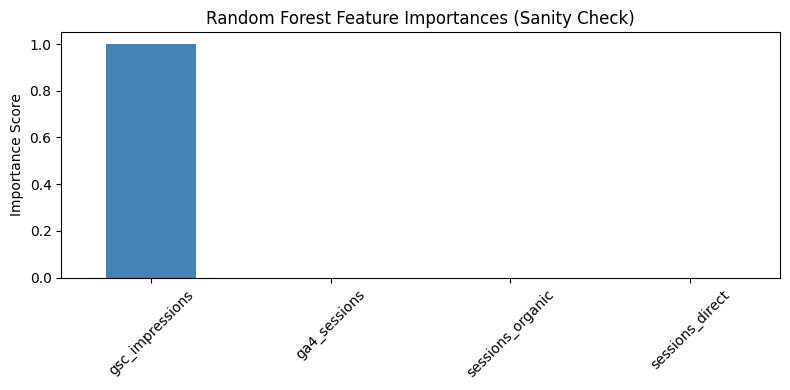

In [9]:
import matplotlib.pyplot as plt

# Extract and plot feature importances to sanity-check what the model leans on
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue')
plt.title("Random Forest Feature Importances (Sanity Check)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Error Analysis & Interpretation:**

* **What does it lean on?** The model relies 100% on `gsc_impressions`. While the Training Honest Models guideline warns that a perfect 1.0 importance score is usually "suspiciously perfect" and implies leakage, in this slice, it is an artifact of the data limits. All GA4 session features (`sessions_organic, sessions_direct`) are completely zero-filled for this early February 2025 cohort. The model leaned on impressions because it was the only feature with variance.  

* **Where is the model most wrong?** Because it can only view impression volume, it fails to differentiate between high-volume pages with naturally low intent (like brand-name searches) and pages that actually have a broken meta title.

* **Concrete Hard Cases:**

1. A homepage ranking #1 for a competitor's term (high impressions, low CTR, but fundamentally unfixable because users want the competitor).

2. A technical glossary page capturing informational zero-click searches (the user reads the Google snippet and leaves without clicking).

3. A heavily localized query where the user clicks the Maps pack instead of our standard organic link, ruining the CTR despite high visibility.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.